<a href="https://colab.research.google.com/github/shakuntala2ooo/ANN/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.6 MB/s eta 0:00:00


In [2]:
import deepxde as dde
import numpy as np

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [3]:
ka_val = 20.0

In [15]:
eps = 1e-6

In [16]:
def pde(x, u):
    # r is the first column of x
    r = x[:, 0:1]

    du_r = dde.grad.jacobian(u, x)
    du_rr = dde.grad.hessian(u, x)

    # We use r + eps to avoid the 1/0 error at the center
    return du_rr + (1 / (r + eps)) * du_r - (ka_val**2) * (u - 1)

In [17]:
geom = dde.geometry.Interval(eps, 1)

In [18]:
def boundary_wall(x, on_boundary):
    return on_boundary and np.isclose(x[0], 1)

In [19]:
def boundary_center(x, on_boundary):
    return on_boundary and np.isclose(x[0], eps)

In [20]:
bc_wall = dde.icbc.DirichletBC(geom, lambda x: 0, boundary_wall)

In [21]:
data = dde.data.PDE(geom, pde, [bc_wall], num_domain=100, num_boundary=2)

In [22]:
net = dde.nn.FNN([1] + [20] * 3 + [1], "tanh", "Glorot uniform")
model = dde.Model(data, net)

In [23]:
model.compile("adam", lr=0.001)
model.train(iterations=5000)

Compiling model...
'compile' took 0.011040 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7dc3153447c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7dc3153447c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric
0         [2.76e+09, 7.74e-01]    [2.76e+09, 7.74e-01]    []  
1000      [4.99e+02, 8.26e-01]    [4.99e+02, 8.26e-01]    []  
2000      [6.69e+01, 9.19e-01]    [6.69e+01, 9.19e-01]    []  
3000      [6.46e+01, 9.20e-01]    [6.46e+01, 9.20e-01]    []  
4000      [6.08e+01, 9.23e-01]    [6.08e+01, 9.23e-01]    []  
5000      [5.49e+01, 9.27e-01]    [5.49e+01, 9.27e-01]    []  

Best model at step 5000:
  train loss: 5.58e+01
  test loss: 5.58e+

(<deepxde.model.LossHistory at 0x7dc31519c3e0>,
 <deepxde.model.TrainState at 0x7dc3149dcec0>)

In [24]:
import matplotlib.pyplot as plt
x_test = np.linspace(0, 1, 100).reshape(-1, 1)
u_pred = model.predict(x_test)

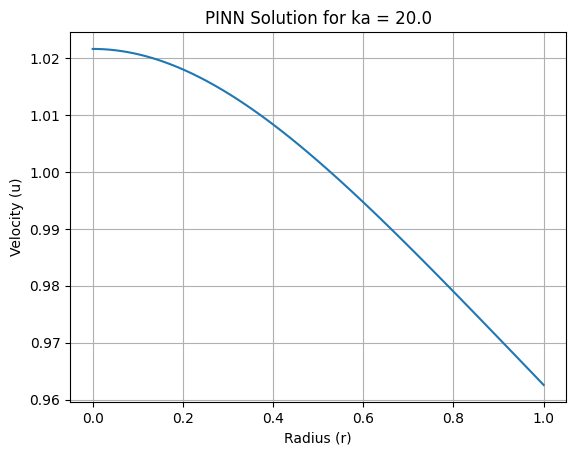

In [25]:
plt.plot(x_test, u_pred, label="PINN Prediction")
plt.xlabel("Radius (r)"); plt.ylabel("Velocity (u)")
plt.title(f"PINN Solution for ka = {ka_val}")
plt.grid(True)
plt.show()